In [1]:
!pip install -U ultralytics

In [ ]:
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
import torch
print(f"Torch version: {torch.__version__}")
import cv2
import numpy as np
from ultralytics import YOLO
import os
from PIL import Image
from torchvision import transforms
from IPython.display import display, clear_output 
from collections import defaultdict



Ultralytics version: 8.4.21
Torch version: 2.5.1


In [16]:

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.rand(10000,10000).to(device)
print(x.device)

2.5.1
None
False


AssertionError: Torch not compiled with CUDA enabled

In [17]:
!nvidia-smi

Mon Mar  9 22:20:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71                 Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   39C    P8             22W /  220W |    1089MiB /   8192MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [31]:
model = YOLO('yolo26n.pt')
video_path = r"data\traffic.mp4"
cap = cv2.VideoCapture(video_path)

In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

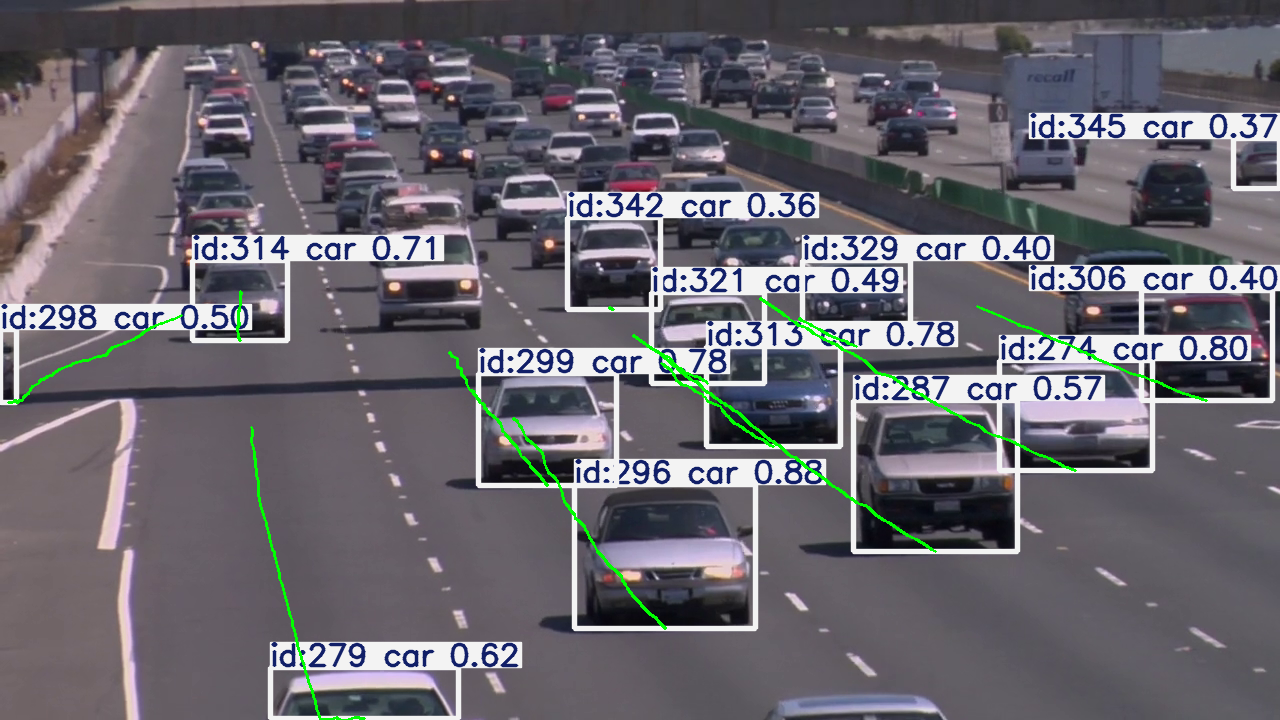

Save Video


In [33]:
import cv2
import numpy as np
from collections import defaultdict
from PIL import Image
from IPython.display import display, clear_output


frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('trajectory.mp4', fourcc, fps, (frame_width, frame_height))

track_history = defaultdict(lambda: [])

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            source=frame, 
            conf=0.3, 
            persist=True,  
            verbose=False, 
            classes=[2, 3, 5, 7], 
            device=0 if device == 'cuda' else 'cpu'
        )

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xywh.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()
            
            annotated_frame = results[0].plot()

            for box, track_id in zip(boxes, track_ids):
                x, y, w, h = box
                track = track_history[track_id]
                track.append((float(x), float(y + h/2)))  
                
                points = np.array(track).astype(np.int32).reshape((-1, 1, 2))
                cv2.polylines(annotated_frame, [points], isClosed=False, color=(0, 255, 0), thickness=2)

        else:
            annotated_frame = results[0].plot()


        out.write(annotated_frame)
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(annotated_frame_rgb)

        clear_output(wait=True)
        display(img)

except KeyboardInterrupt:
    print("Stopped")

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print("Save Video")